<a href="https://colab.research.google.com/github/Limsungrae/Hongong/blob/main/%ED%98%BC%EA%B3%B5%EB%A8%B8%EC%8B%A0_9_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 순환 신경망으로 IMDB 리뷰 분류하기

> 인용구 추가



In [19]:
# 실행마다 동일한 결과를 얻기 위해 케라스에 랜덤 시드를 사용하고 텐서플로 연산을 결정적으로 만듭니다.
import keras
import tensorflow as tf

keras.utils.set_random_seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()

### IMDB 리뷰 데이터셋

In [20]:
from keras.datasets import imdb

# IMDB 데이터셋 로드: 가장 자주 등장하는 단어 200개만 사용합니다.
(train_input, train_target), (test_input, test_target) = imdb.load_data(
    num_words=200)

In [21]:
# 훈련 세트와 테스트 세트의 형태를 출력합니다.
print(train_input.shape, test_input.shape)

(25000,) (25000,)


In [22]:
# 첫 번째 훈련 리뷰의 길이를 출력합니다.
print(len(train_input[0]))

218


In [23]:
# 두 번째 훈련 리뷰의 길이를 출력합니다.
print(len(train_input[1]))

189


In [24]:
# 첫 번째 훈련 리뷰 내용을 출력합니다 (단어로 변환된 숫자 시퀀스).
print(train_input[0])

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 2, 2, 66, 2, 4, 173, 36, 2, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 2, 2, 5, 150, 4, 172, 112, 167, 2, 2, 2, 39, 4, 172, 2, 2, 17, 2, 38, 13, 2, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 2, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 2, 12, 8, 2, 8, 106, 5, 4, 2, 2, 16, 2, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 2, 28, 77, 52, 5, 14, 2, 16, 82, 2, 8, 4, 107, 117, 2, 15, 2, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 2, 26, 2, 2, 46, 7, 4, 2, 2, 13, 104, 88, 4, 2, 15, 2, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 2, 22, 21, 134, 2, 26, 2, 5, 144, 30, 2, 18, 51, 36, 28, 2, 92, 25, 104, 4, 2, 65, 16, 38, 2, 88, 12, 16, 2, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


In [25]:
# 처음 20개 훈련 타겟(레이블)을 출력합니다 (1은 긍정, 0은 부정).
print(train_target[:20])

[1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 1]


In [26]:
from sklearn.model_selection import train_test_split

# 훈련 세트에서 검증 세트를 20% 분리합니다.
train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

In [27]:
import numpy as np

# 각 리뷰의 길이를 계산하여 numpy 배열로 저장합니다.
lengths = np.array([len(x) for x in train_input])

In [28]:
# 리뷰 길이의 평균과 중앙값을 출력합니다.
print(np.mean(lengths), np.median(lengths))

239.00925 178.0


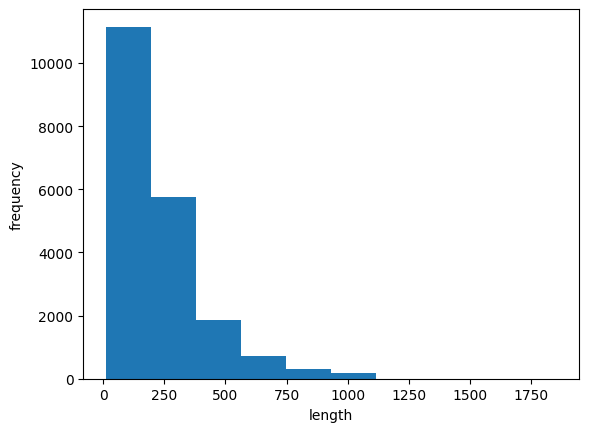

In [29]:
import matplotlib.pyplot as plt

# 리뷰 길이 분포를 히스토그램으로 그립니다.
plt.hist(lengths)
plt.xlabel('length')
plt.ylabel('frequency')
plt.show()

In [30]:
from keras.preprocessing.sequence import pad_sequences

# 훈련 입력 시퀀스의 길이를 100으로 맞춥니다. (짧은 시퀀스는 0으로 채우고, 긴 시퀀스는 자릅니다.)
train_seq = pad_sequences(train_input, maxlen=100)

In [31]:
# 패딩된 훈련 시퀀스의 형태를 출력합니다.
print(train_seq.shape)

(20000, 100)


In [32]:
# 패딩된 첫 번째 훈련 시퀀스를 출력합니다.
print(train_seq[0])

[ 10   4  20   9   2   2   2   5  45   6   2   2  33   2   8   2 142   2
   5   2  17  73  17   2   5   2  19  55   2   2  92  66 104  14  20  93
  76   2 151  33   4  58  12 188   2 151  12   2  69   2 142  73   2   6
   2   7   2   2 188   2 103  14  31  10  10   2   7   2   5   2  80  91
   2  30   2  34  14  20 151  50  26 131  49   2  84  46  50  37  80  79
   6   2  46   7  14  20  10  10   2 158]


In [33]:
# 원본 첫 번째 훈련 리뷰의 마지막 10개 단어를 출력합니다.
print(train_input[0][-10:])

[6, 2, 46, 7, 14, 20, 10, 10, 2, 158]


In [34]:
# 패딩된 다섯 번째 훈련 시퀀스를 출력합니다.
print(train_seq[5])

[  0   0   0   0   1   2 195  19  49   2   2 190   4   2   2   2 183  10
  10  13  82  79   4   2  36  71   2   8   2  25  19  49   7   4   2   2
   2   2   2  10  10  48  25  40   2  11   2   2  40   2   2   5   4   2
   2  95  14   2  56 129   2  10  10  21   2  94   2   2   2   2  11 190
  24   2   2   7  94   2   2  10  10  87   2  34  49   2   7   2   2   2
   2   2   2   2  46  48  64  18   4   2]


In [35]:
# 검증 입력 시퀀스의 길이를 100으로 맞춥니다.
val_seq = pad_sequences(val_input, maxlen=100)

#### 순환 신경망 만들기 (566p)

In [37]:
import keras

# Sequential 모델은 층을 순서대로 쌓아 올린 가장 간단한 신경망 모델입니다.
# 여기서는 IMDB 리뷰를 분류하기 위한 순환 신경망(RNN) 모델을 만듭니다.
model = keras.Sequential()

# Input 층은 모델이 받아들일 데이터의 형태(shape)를 정의합니다.
# (100, 200)은 각 리뷰가 100개의 단어로 이루어져 있고, 각 단어는 200차원(one-hot encoding)으로 표현된다는 의미입니다.
# 즉, 길이가 100인 시퀀스이며 각 시퀀스의 아이템(단어)이 200개의 특징을 가집니다.
model.add(keras.layers.Input(shape=(100,200)))

# SimpleRNN 층은 가장 기본적인 순환 신경망 층입니다.
# 8은 이 RNN 층이 가지는 은닉 상태(hidden state)의 크기 또는 유닛(unit)의 개수를 의미합니다.
# 이 유닛들이 이전 시점의 정보와 현재 시점의 입력을 바탕으로 새로운 정보를 학습하고 전달합니다.
model.add(keras.layers.SimpleRNN(8))

# Dense 층은 완전 연결(fully connected) 층으로, 신경망의 마지막 단계에서 예측을 수행합니다.
# 1은 출력 유닛의 개수로, 이진 분류(긍정/부정)이므로 1개의 출력을 가집니다.
# 'sigmoid' 활성화 함수는 출력을 0과 1 사이의 값으로 압축하여 확률처럼 해석할 수 있게 합니다.
# 0에 가까우면 부정, 1에 가까우면 긍정을 의미합니다.
model.add(keras.layers.Dense(1, activation='sigmoid'))

In [38]:
# train_seq는 단어 인덱스로 이루어진 시퀀스입니다. SimpleRNN 층에 직접 입력하려면,
# 각 단어 인덱스를 원-핫 인코딩(one-hot encoding) 벡터로 변환해야 합니다.
# 예를 들어, 단어 사전의 크기가 200이라면, 100번째 단어는 100번째 요소만 1이고 나머지는 0인 200차원 벡터로 변환됩니다.
# keras.utils.to_categorical 함수가 이 역할을 수행합니다.
train_oh = keras.utils.to_categorical(train_seq)

In [39]:
# 원-핫 인코딩된 훈련 데이터의 형태를 확인합니다.
# (20000, 100, 200)은 20,000개의 샘플(리뷰), 각 샘플은 100개의 단어, 각 단어는 200차원의 원-핫 벡터로 표현된다는 뜻입니다.
print(train_oh.shape)

(20000, 100, 200)


In [40]:
# 첫 번째 훈련 샘플(리뷰)의 첫 번째 단어가 어떻게 원-핫 인코딩되었는지 앞부분 12개 요소를 출력하여 확인합니다.
# 1.0이 있는 위치가 해당 단어의 인덱스를 나타냅니다. 예를 들어, [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.] 이라면 10번 인덱스 단어입니다.
print(train_oh[0][0][:12])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


In [41]:
# 원-핫 인코딩된 벡터는 한 단어에 대해 단 하나의 '1' 값을 가져야 합니다.
# 첫 번째 훈련 샘플의 첫 번째 단어 벡터의 모든 요소를 합하면 1이 나와야 정확히 원-핫 인코딩된 것을 확인할 수 있습니다.
print(np.sum(train_oh[0][0]))

1.0


In [42]:
# 훈련 데이터와 마찬가지로 검증 데이터도 SimpleRNN 모델의 입력 형태에 맞게 원-핫 인코딩으로 변환합니다.
val_oh = keras.utils.to_categorical(val_seq)

In [43]:
# model.summary()는 모델의 각 층에 대한 자세한 정보를 보여줍니다.
# 층의 이름, 출력 형태(Output Shape), 층이 학습하는 파라미터(가중치와 편향)의 개수를 확인할 수 있습니다.
# 이를 통해 모델의 복잡도와 구조를 한눈에 파악할 수 있습니다.
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 8)              │         1,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,681 (6.57 KB)

 Trainable params: 1,681 (6.57 KB)

 Non-trainable params: 0 (0.00 B)

### 순환 신경망 훈련하기

In [44]:
# 모델을 훈련하기 전에 compile() 메서드를 사용하여 모델의 훈련 방식을 설정합니다.
# optimizer='adam': 모델의 가중치를 업데이트하는 '최적화 알고리즘'으로 'Adam'을 사용합니다. Adam은 효율적이고 많이 사용되는 알고리즘 중 하나입니다.
# loss='binary_crossentropy': 이진 분류 문제에 적합한 '손실 함수'입니다. 모델의 예측과 실제 값 사이의 오차를 계산합니다.
# metrics=['accuracy']: 모델의 '성능 지표'로 '정확도(accuracy)'를 사용합니다. 훈련 중 모델이 얼마나 정확하게 예측하는지 보여줍니다.
model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])

# ModelCheckpoint 콜백은 훈련 중 가장 좋은 성능을 보인 모델의 가중치를 자동으로 저장합니다.
# 'best-simplernn-model.keras' 파일로 저장되며, 'save_best_only=True' 옵션으로 최고 성능 모델만 저장하도록 설정합니다.
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-simplernn-model.keras',
                                                save_best_only=True)
# EarlyStopping 콜백은 모델이 더 이상 개선되지 않을 때 훈련을 조기에 중단하여 과대적합(overfitting)을 방지합니다.
# 'patience=3': 검증 손실(validation loss)이 3 에포크 동안 개선되지 않으면 훈련을 중단합니다.
# 'restore_best_weights=True': 훈련 중 가장 좋았던 시점의 모델 가중치로 되돌립니다.
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)

# model.fit() 메서드를 사용하여 모델을 훈련합니다.
# train_oh: 훈련 입력 데이터 (원-핫 인코딩된 리뷰 시퀀스)
# train_target: 훈련 타겟 레이블 (긍정/부정)
# epochs=100: 전체 훈련 데이터를 100번 반복하여 학습합니다.
# batch_size=64: 한 번에 64개의 샘플을 사용하여 가중치를 업데이트합니다. (더 작은 묶음으로 학습)
# validation_data=(val_oh, val_target): 모델의 과대적합 여부를 확인하기 위해 검증 데이터를 사용합니다.
# callbacks: 위에서 정의한 ModelCheckpoint와 EarlyStopping 콜백을 적용합니다.
history = model.fit(train_oh, train_target, epochs=100, batch_size=64,
                    validation_data=(val_oh, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.5107 - loss: 0.6972 - val_accuracy: 0.5288 - val_loss: 0.6906
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.5443 - loss: 0.6864 - val_accuracy: 0.5508 - val_loss: 0.6844
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5921 - loss: 0.6666 - val_accuracy: 0.6734 - val_loss: 0.6140
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.6873 - loss: 0.5949 - val_accuracy: 0.7026 - val_loss: 0.5738
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.7149 - loss: 0.5670 - val_accuracy: 0.7184 - val_loss: 0.5609
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7177 - loss: 0.5602 - val_accuracy: 0.7214 - val_loss: 0.5545
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.7260 - loss: 0.5512 - val_accuracy: 0.7286 - val_loss: 0.5498
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7247 - loss: 0.5511 

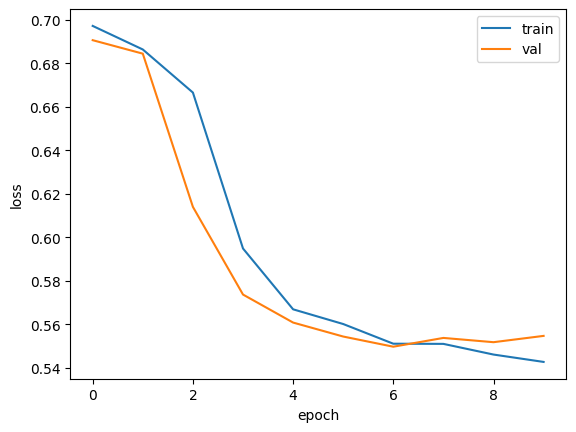

In [45]:
# 훈련 과정에서 기록된 손실(loss) 값을 그래프로 시각화하여 모델의 학습 추이를 분석합니다.
# plt.plot(history.history['loss'], label='train'): 훈련 세트에 대한 손실 변화를 파란색 선으로 그립니다.
# plt.plot(history.history['val_loss'], label='val'): 검증 세트에 대한 손실 변화를 주황색 선으로 그립니다.
# plt.xlabel('epoch'): x축 레이블을 'epoch'(훈련 반복 횟수)로 설정합니다.
# plt.ylabel('loss'): y축 레이블을 'loss'(손실 값)로 설정합니다.
# plt.legend(): 범례를 표시하여 각 선이 무엇을 나타내는지 쉽게 알 수 있게 합니다.
# plt.show(): 그래프를 화면에 출력합니다.
# 이 그래프를 통해 훈련 손실과 검증 손실의 변화를 비교하며 과대적합(overfitting)이나 과소적합(underfitting) 여부를 판단할 수 있습니다.
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

### 단어 임베딩을 사용하기

In [46]:
(train_input, train_target), (test_input, test_target) = imdb.load_data(
    num_words=500)
train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)
train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [47]:
model_emb = keras.Sequential()
model_emb.add(keras.layers.Input(shape=(100,)))
model_emb.add(keras.layers.Embedding(500, 16))
model_emb.add(keras.layers.SimpleRNN(8))
model_emb.add(keras.layers.Dense(1, activation='sigmoid'))

In [49]:
model_emb.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,209 (32.07 KB)

 Trainable params: 8,209 (32.07 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
model_emb.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-embedding-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)

history = model_emb.fit(train_seq, train_target, epochs=100, batch_size=64,
                        validation_data=(val_seq, val_target),
                        callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.5489 - loss: 0.6863 - val_accuracy: 0.5782 - val_loss: 0.6750
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.6771 - loss: 0.6061 - val_accuracy: 0.6992 - val_loss: 0.5848
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7434 - loss: 0.5338 - val_accuracy: 0.7418 - val_loss: 0.5404
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7704 - loss: 0.4953 - val_accuracy: 0.7242 - val_loss: 0.5623
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.7846 - loss: 0.4761 - val_accuracy: 0.7614 - val_loss: 0.5077
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7962 - loss: 0.4561 - val_accuracy: 0.7608 - val_loss: 0.5175
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8005 - loss: 0.4471 - val_accuracy: 0.7606 - val_loss: 0.5080
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8110 - loss: 0.4314 

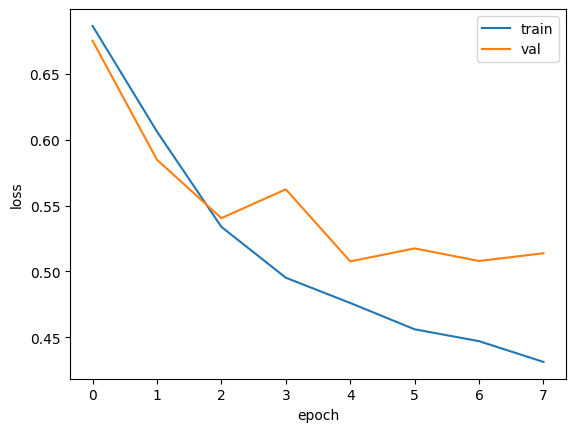

In [51]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()